In [ ]:
import os, cv2, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [ ]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/IDC.zip"   # update if your path differs
extract_dir = "/content/IDC"

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    print("Extracted IDC to:", extract_dir)
else:
    print("IDC directory already exists at:", extract_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IDC directory already exists at: /content/IDC


In [ ]:
import os
from glob import glob

# Colab path after extracting IDC.zip
DATA_DIR = "/content/IDC/IDC_regular_ps50_idx5"

# Collect all image paths recursively
imagePatches = glob(os.path.join(DATA_DIR, "**", "*.png"), recursive=True)

print("Total patches:", len(imagePatches))
print("Example file:", imagePatches[0] if len(imagePatches) > 0 else "No images found")


Total patches: 277524
Example file: /content/IDC/IDC_regular_ps50_idx5/12880/1/12880_idx5_x401_y1001_class1.png


In [ ]:
def load_images(imagePaths, limit=None):
    data, labels = [], []
    WIDTH, HEIGHT = 50, 50
    for i, path in enumerate(imagePaths):
        if limit and i >= limit:
            break
        img = cv2.imread(path)
        img = cv2.resize(img, (WIDTH, HEIGHT))
        data.append(img)
        label = 1 if "class1" in path else 0
        labels.append(label)
    return np.array(data), np.array(labels)

# Load subset for speed (e.g. 90k samples)
X, y = load_images(imagePatches, limit=90000)

print("Data shape:", X.shape)
print("Labels distribution:", np.bincount(y))


Data shape: (90000, 50, 50, 3)
Labels distribution: [66288 23712]


In [ ]:
X = X.astype("float32") / 255.0
Y = to_categorical(y, num_classes=2)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (72000, 50, 50, 3)
Test shape: (18000, 50, 50, 3)


In [ ]:
# =====================================================
# STEP 2: Data Generators (Balanced Loading)
# =====================================================
IMG_SIZE = (50,50)
BATCH_SIZE = 64

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print("Class mapping:", train_gen.class_indices)  # e.g. {'0':0, '1':1}


Found 222127 images belonging to 279 classes.
Found 55397 images belonging to 279 classes.
Class mapping: {'10253': 0, '10254': 1, '10255': 2, '10256': 3, '10257': 4, '10258': 5, '10259': 6, '10260': 7, '10261': 8, '10262': 9, '10264': 10, '10268': 11, '10269': 12, '10272': 13, '10273': 14, '10274': 15, '10275': 16, '10276': 17, '10277': 18, '10278': 19, '10279': 20, '10282': 21, '10285': 22, '10286': 23, '10288': 24, '10290': 25, '10291': 26, '10292': 27, '10293': 28, '10295': 29, '10299': 30, '10300': 31, '10301': 32, '10302': 33, '10303': 34, '10304': 35, '10305': 36, '10306': 37, '10307': 38, '10308': 39, '12241': 40, '12242': 41, '12626': 42, '12748': 43, '12749': 44, '12750': 45, '12751': 46, '12752': 47, '12810': 48, '12811': 49, '12817': 50, '12818': 51, '12819': 52, '12820': 53, '12821': 54, '12822': 55, '12823': 56, '12824': 57, '12826': 58, '12867': 59, '12868': 60, '12869': 61, '12870': 62, '12871': 63, '12872': 64, '12873': 65, '12875': 66, '12876': 67, '12877': 68, '12878

In [ ]:
def build_cnn(input_shape=(50,50,3)):
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(2, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,273,666 (4.86 MB)

 Trainable params: 1,273,666 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 30
BATCH_SIZE = 128
history_cnn = cnn_model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, Y_test),
    verbose=1
)


Epoch 1/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 436s 770ms/step - accuracy: 0.7920 - loss: 0.4617 - val_accuracy: 0.8418 - val_loss: 0.3578
Epoch 2/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 423s 752ms/step - accuracy: 0.8384 - loss: 0.3743 - val_accuracy: 0.8519 - val_loss: 0.3391
Epoch 3/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 424s 753ms/step - accuracy: 0.8529 - loss: 0.3453 - val_accuracy: 0.8642 - val_loss: 0.3264
Epoch 4/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 450s 767ms/step - accuracy: 0.8627 - loss: 0.3275 - val_accuracy: 0.8624 - val_loss: 0.3238
Epoch 5/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 449s 780ms/step - accuracy: 0.8693 - loss: 0.3158 - val_accuracy: 0.8647 - val_loss: 0.3215
Epoch 6/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 427s 758ms/step - accuracy: 0.8738 - loss: 0.3064 - val_accuracy: 0.8621 - val_loss: 0.3443
Epoch 7/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 427s 758ms/step - accuracy: 0.8752 - loss: 0.3027 - val_accuracy: 0.8814 - val_loss: 0.2882
Epoch 8/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 423s 725ms/step - accuracy: 0.8813 -

In [ ]:
def build_resnet(input_shape=(50,50,3)):
    base = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    for layer in base.layers:
        layer.trainable = False  # freeze backbone

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    out = Dense(2, activation="softmax")(x)

    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model


In [ ]:
resnet_model = build_resnet()
resnet_model.summary()

history_resnet = resnet_model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=5,
    batch_size=128,
    verbose=1
)


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50, 50, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 56, 56, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 25, 25,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 25, 25,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 25, 25,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 27, 27,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 13, 13,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 13, 13,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 13, 13,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 13, 13,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 13, 13,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 13, 13,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 13, 13,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 13, 13,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 13, 13,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 13, 13,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 13, 13,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7134 - loss: 0.6130

KeyboardInterrupt: 

563/563 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step
Custom CNN -> Accuracy=0.264, Precision=0.263, Recall=0.999, F1=0.417, AUC=0.382


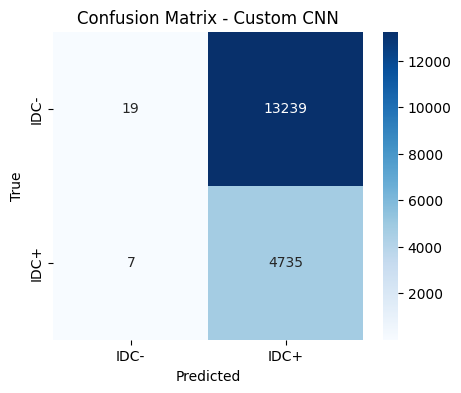

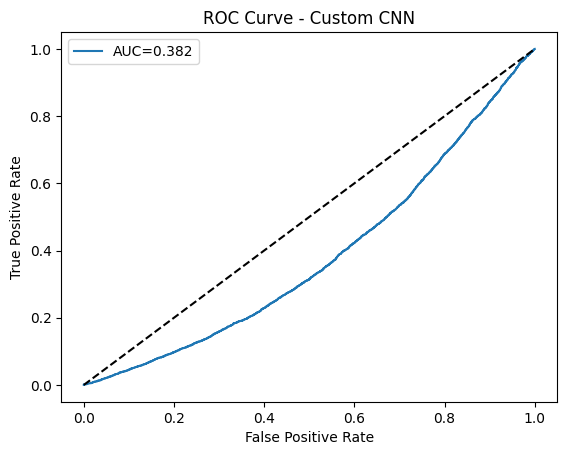

563/563 ━━━━━━━━━━━━━━━━━━━━ 238s 420ms/step
ResNet50 -> Accuracy=0.737, Precision=0.000, Recall=0.000, F1=0.000, AUC=0.719


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


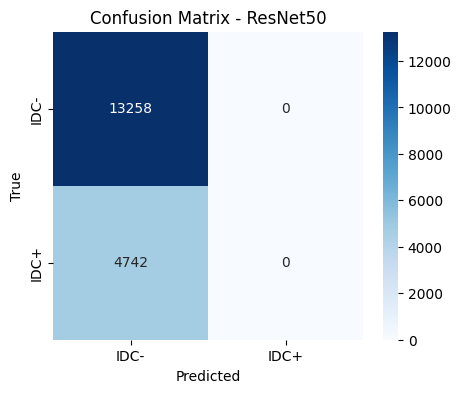

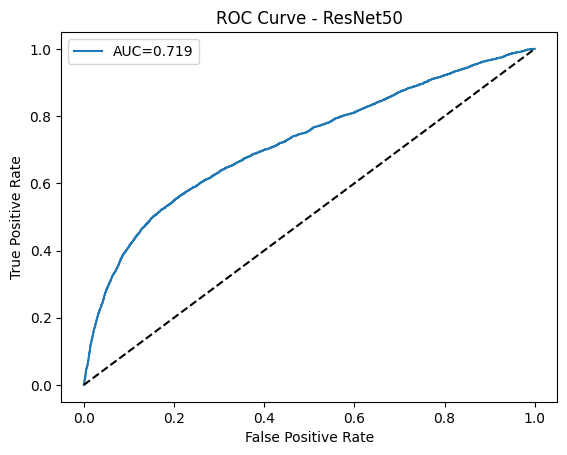

In [ ]:
def evaluate_model(model, X, Y, model_name="Model"):
    y_true = np.argmax(Y, axis=1)
    y_prob = model.predict(X)
    y_pred = np.argmax(y_prob, axis=1)

    acc = (y_pred == y_true).mean()
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_prob[:,1])

    print(f"{model_name} -> Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}, AUC={auc_score:.3f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["IDC-","IDC+"], yticklabels=["IDC-","IDC+"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])
    plt.plot(fpr, tpr, label=f"AUC={auc_score:.3f}")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

# Evaluate CNN
evaluate_model(cnn_model, X_test, Y_test, "Custom CNN")
# Evaluate ResNet50
evaluate_model(resnet_model, X_test, Y_test, "ResNet50")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 372ms/step


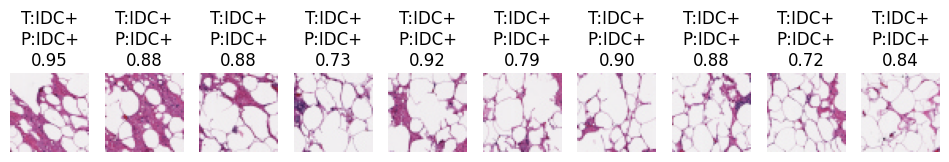

In [ ]:
X_val, y_val = next(val_gen)
preds = resnet_model.predict(X_val)

plt.figure(figsize=(12,6))
for i in range(10):
    prob = preds[i][0]
    true_label = "IDC+"
    pred_label = "IDC+" if prob>0.5 else "IDC-"

    plt.subplot(1,10,i+1)
    plt.imshow(X_val[i])
    plt.title(f"T:{true_label}\nP:{pred_label}\n{prob:.2f}")
    plt.axis("off")
plt.show()


In [ ]:
# 1) Verify mapping & generator properties
import math, os
print("train_gen exists?", 'train_gen' in globals())
print("val_gen exists?", 'val_gen' in globals())

# Print mapping and some metadata
print("train_gen.class_indices:", getattr(train_gen, 'class_indices', None))
print("val_gen.class_indices:", getattr(val_gen, 'class_indices', None))
print("val_gen.samples:", getattr(val_gen, 'samples', None))
print("val_gen.batch_size:", getattr(val_gen, 'batch_size', None))
print("Number of filenames in val_gen:", len(getattr(val_gen, 'filenames', [])))
print("shuffle in val_gen:", getattr(val_gen, 'shuffle', None))

# Make sure the validation generator was created with shuffle=False (recommended)
# If shuffle=True, recreate it with shuffle=False:
if getattr(val_gen, 'shuffle', True):
    print("Recreating val_gen with shuffle=False (so filename index <-> label index is stable)...")
    # Recreate val_gen (you can re-run this only if necessary)
    datagen = train_gen.image_data_generator  # reuse same datagen if possible
    val_gen = datagen.flow_from_directory(
        train_gen.directory,
        target_size=train_gen.target_size,
        batch_size=train_gen.batch_size,
        class_mode='binary',
        subset='validation',
        shuffle=False)
    print("Done. New val_gen.shuffle:", val_gen.shuffle)


train_gen exists? True
val_gen exists? True
train_gen.class_indices: {'10253': 0, '10254': 1, '10255': 2, '10256': 3, '10257': 4, '10258': 5, '10259': 6, '10260': 7, '10261': 8, '10262': 9, '10264': 10, '10268': 11, '10269': 12, '10272': 13, '10273': 14, '10274': 15, '10275': 16, '10276': 17, '10277': 18, '10278': 19, '10279': 20, '10282': 21, '10285': 22, '10286': 23, '10288': 24, '10290': 25, '10291': 26, '10292': 27, '10293': 28, '10295': 29, '10299': 30, '10300': 31, '10301': 32, '10302': 33, '10303': 34, '10304': 35, '10305': 36, '10306': 37, '10307': 38, '10308': 39, '12241': 40, '12242': 41, '12626': 42, '12748': 43, '12749': 44, '12750': 45, '12751': 46, '12752': 47, '12810': 48, '12811': 49, '12817': 50, '12818': 51, '12819': 52, '12820': 53, '12821': 54, '12822': 55, '12823': 56, '12824': 57, '12826': 58, '12867': 59, '12868': 60, '12869': 61, '12870': 62, '12871': 63, '12872': 64, '12873': 65, '12875': 66, '12876': 67, '12877': 68, '12878': 69, '12879': 70, '12880': 71, '128

Saving 16568_idx5_x151_y951_class0.png to 16568_idx5_x151_y951_class0 (2).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Prediction: IDC+ (Cancerous) (Probability IDC+ = 0.780)


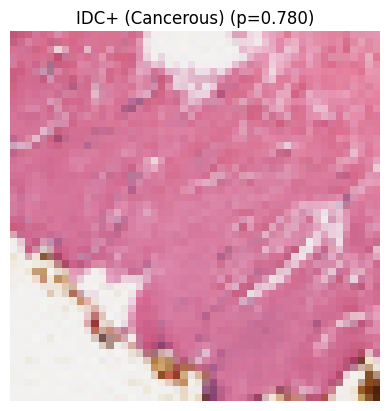

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Upload image
uploaded = files.upload()
for fn in uploaded.keys():
    img_path = fn

# Preprocess the uploaded image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (50,50))
img_norm = img_resized.astype("float32") / 255.0
img_input = np.expand_dims(img_norm, axis=0)

# Predict with ResNet (sigmoid output -> probability of IDC+)
prob = resnet_model.predict(img_input)[0][0]   # single probability
label = "IDC+ (Cancerous)" if prob > 0.5 else "IDC- (Non-Cancerous)"

print(f"Prediction: {label} (Probability IDC+ = {prob:.3f})")

# Show image with predicted label
plt.imshow(img_resized)
plt.title(f"{label} (p={prob:.3f})")
plt.axis("off")
plt.show()
